<a href="https://colab.research.google.com/github/Deepak-212/UAV-Path-Planning/blob/main/Dynamic_env_planning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import heapq
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


class GridEnvironment:
    def __init__(self, shape=(20, 20, 10)):
        self.shape = shape
        self.grid = np.zeros(shape, dtype=int)

    def add_obstacle_block(self, x_range, y_range, z_range):
        self.grid[x_range[0]:x_range[1],
                  y_range[0]:y_range[1],
                  z_range[0]:z_range[1]] = 1

    def is_free(self, x, y, z, t, dynamic_obstacles):
        # 1. Static boundary and obstacle check
        if not (0 <= x < self.shape[0] and
                0 <= y < self.shape[1] and
                0 <= z < self.shape[2]):
            return False
        if self.grid[x, y, z] == 1:
            return False

        # 2. Dynamic obstacle check
        for obs in dynamic_obstacles:
            if obs.position_at(t) == (x, y, z):
                return False
        return True

class DynamicObstacle:
    def __init__(self, waypoints, loop=True, name="Obs"):
        self.waypoints = waypoints
        self.loop = loop
        self.name = name

    def position_at(self, t):
        if self.loop:
            return self.waypoints[t % len(self.waypoints)]
        else:
            idx = min(t, len(self.waypoints) - 1)
            return self.waypoints[idx]

def move_cost(cur, nxt):
    dx, dy, dz = nxt[0]-cur[0], nxt[1]-cur[1], nxt[2]-cur[2]
    dist = math.sqrt(dx**2 + dy**2 + dz**2)
    # 0.5 penalty for climbing, 0 cost if waiting in place
    return dist + max(0, dz) * 0.5

def heuristic(node, goal):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(node, goal)))

def astar_spacetime(env, start, goal, dynamic_obstacles, t_max=100):
    start_state = (*start, 0) # (x, y, z, t)
    open_heap = [(0, start_state)]
    came_from = {start_state: None}
    g_score = {start_state: 0.0}

    while open_heap:
        _, current = heapq.heappop(open_heap)
        cx, cy, cz, ct = current

        if (cx, cy, cz) == goal:
            path = []
            while current:
                path.append(current[:3])
                current = came_from[current]
            return path[::-1], g_score[(*goal, ct)], ct

        if ct >= t_max:
            continue

        # 26 moves + 1 stay-in-place move
        moves = [(dx, dy, dz) for dx in [-1,0,1] for dy in [-1,0,1] for dz in [-1,0,1]]

        for dx, dy, dz in moves:
            nx, ny, nz = cx+dx, cy+dy, cz+dz
            nt = ct + 1

            if not env.is_free(nx, ny, nz, nt, dynamic_obstacles):
                continue

            cost = move_cost((cx,cy,cz), (nx,ny,nz))
            tg = g_score[current] + cost
            neighbor_state = (nx, ny, nz, nt)

            if tg < g_score.get(neighbor_state, float('inf')):
                g_score[neighbor_state] = tg
                came_from[neighbor_state] = current
                f = tg + heuristic((nx,ny,nz), goal)
                heapq.heappush(open_heap, (f, neighbor_state))

    return [], float('inf'), -1

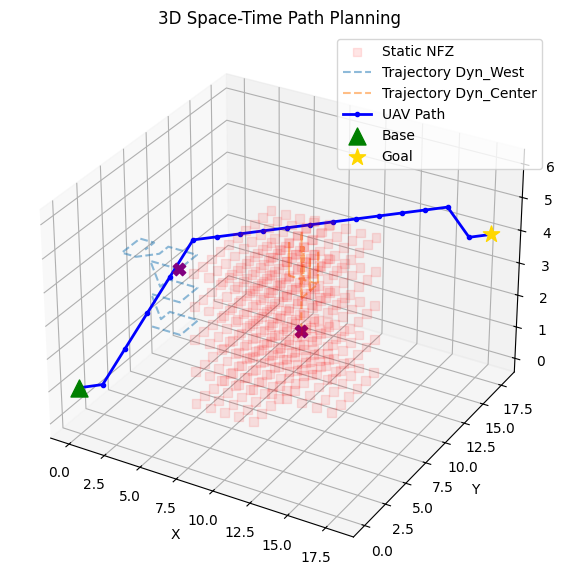

In [ ]:
# --- Execution ---
# single uav
env = GridEnvironment(shape=(20, 20, 10))
env.add_obstacle_block((5, 10), (5, 15), (0, 5))
env.add_obstacle_block((12, 17), (2, 8), (2, 7))

BASE = (0, 0, 1)
TARGET = (18, 18, 4)

# Dynamic Obstacles
# Obstacle 1: Moves in a more complex pattern in the west side
obs1_waypoints = [
    (2,5,2), (3,5,2), (4,5,2), (4,6,2), (4,7,2), (3,7,2), (2,7,2), (2,6,2), # Original loop
    (2,5,3), (3,5,3), (4,5,3), (4,6,3), (4,7,3), (3,7,3), (2,7,3), (2,6,3), # Same loop, higher Z
    (2,5,4), (3,5,4), (4,5,4), (4,6,4), (4,7,4), (3,7,4), (2,7,4), (2,6,4), # Same loop, even higher Z
    (1,5,4), (0,5,4), (0,6,4), (0,7,4), (1,7,4), (1,6,4) # Extended movement towards (0,y,z)
]

# Obstacle 2: Bounces up and down and moves along the Y-axis in the middle corridor
obs2_waypoints = [
    (10,9,2), (10,9,3), (10,9,4), (10,9,5), (10,9,4), (10,9,3), # Original up/down
    (10,10,3), (10,10,4), (10,10,3), # Move to Y=10
    (10,11,3), (10,11,4), (10,11,3), # Move to Y=11
    (9,11,3), (9,11,4), (9,11,3), # Move to X=9
    (8,11,3), (8,11,4), (8,11,3)  # Move to X=8
]

dynamic_obstacles = [
    DynamicObstacle(obs1_waypoints, loop=True, name="Dyn_West"),
    DynamicObstacle(obs2_waypoints, loop=True, name="Dyn_Center"),
]
path, cost, arrival_t = astar_spacetime(env, BASE, TARGET, dynamic_obstacles)

# --- Visualization ---

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 1. Plot Static Obstacles (NFZs)
x, y, z = np.where(env.grid == 1)
ax.scatter(x, y, z, c='red', marker='s', alpha=0.1, s=40, label='Static NFZ')

# 2. Plot Dynamic Obstacle Trajectories
for obs in dynamic_obstacles:
    ox, oy, oz = zip(*obs.waypoints)
    ax.plot(ox, oy, oz, '--', alpha=0.5, label=f'Trajectory {obs.name}')
    # Mark where the dynamic obstacles end up at arrival time
    if arrival_t != -1:
        px, py, pz = obs.position_at(arrival_t)
        ax.scatter([px], [py], [pz], color='purple', s=80, marker='X')

# 3. Plot UAV Path
if path:
    px, py, pz = zip(*path)
    ax.plot(px, py, pz, '-o', markersize=3, label='UAV Path', color='blue', linewidth=2)

# 4. Markers for Start and Goal
ax.scatter(*BASE, c='green', s=150, marker='^', label='Base')
ax.scatter(*TARGET, c='gold', s=150, marker='*', label='Goal')

ax.set_title("3D Space-Time Path Planning")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.legend()
plt.show()

In [ ]:
# --- Reuse your existing DynamicObstacle and GridEnvironment logic ---

class UAVPathObstacle:
    """Treats a completed UAV path as a dynamic obstacle for other UAVs."""
    def __init__(self, path, name):
        self.path = path  # List of (x, y, z)
        self.name = name

    def position_at(self, t):
        # If t exceeds the path length, the UAV stays at its last position (the target)
        idx = min(t, len(self.path) - 1)
        return self.path[idx]

# --- Modified Planning Loop for 3 UAVs ---

def plan_multi_uav(env, starts, goals, env_dynamic_obstacles):
    all_paths = []
    # Combined list starts with environment hazards (the two moving obstacles you made)
    current_dynamic_obstacles = list(env_dynamic_obstacles)

    colors = ['blue', 'green', 'orange']

    for i in range(len(starts)):
        print(f"Planning for UAV {i+1}...")
        # Debugging print statements
        print(f"  UAV {i+1} Start: {starts[i]}")
        print(f"  UAV {i+1} Goal: {goals[i]}")
        print(f"  UAV {i+1} Current Dynamic Obstacles: {[obs.name for obs in current_dynamic_obstacles]}")

        # Use the spacetime A* we built previously
        path, cost, arrival_t = astar_spacetime(
            env, starts[i], goals[i], current_dynamic_obstacles, t_max=100
        )

        if not path:
            print(f"UAV {i+1} could not find a path!")
            continue

        all_paths.append(path)

        # CRITICAL: Add this UAV's path as an obstacle for the next UAVs
        new_obs = UAVPathObstacle(path, name=f"UAV_{i+1}_Path")
        current_dynamic_obstacles.append(new_obs)

    return all_paths

First, let's install the `moviepy` library, which is excellent for video editing and conversions. This is needed for the GIF to MP4 conversion.

In [ ]:
import sys
!{sys.executable} -m pip install moviepy imageio imageio[ffmpeg]

Now, let's define the function `generate_uav_animation_gif` to create the animated visualizations for both single and multi-UAV scenarios. This function will also automatically convert the generated GIF to an MP4 file.

In [ ]:
import matplotlib.animation as animation
import numpy as np
import matplotlib.pyplot as plt
from moviepy.editor import VideoFileClip

def generate_uav_animation_gif(env, uav_paths_list, env_dynamic_obstacles, starts_list, goals_list, uav_colors, title, filename):
    t_max = 100 # Define t_max for animation, consistent with planning

    # Extend each UAV's path with its final position to cover the full animation duration
    all_extended_uav_paths = []
    for i_uav, (path_uav, goal_uav) in enumerate(zip(uav_paths_list, goals_list)):
        extended_path = list(path_uav)
        while len(extended_path) <= t_max:
            extended_path.append(goal_uav)
        all_extended_uav_paths.append(extended_path)

    max_animation_frames = t_max + 1 # Animation frames up to t_max

    # Create the figure and 3D axis
    fig_anim = plt.figure(figsize=(12, 8))
    ax_anim = fig_anim.add_subplot(111, projection='3d')

    # Plot static obstacles once
    x_static, y_static, z_static = np.where(env.grid == 1)
    ax_anim.scatter(x_static, y_static, z_static, c='red', marker='s', alpha=0.1, s=40, label='Static NFZ')

    # Plot environmental dynamic obstacle trajectories (as background)
    for obs in env_dynamic_obstacles:
        ox, oy, oz = zip(*obs.waypoints)
        ax_anim.plot(ox, oy, oz, ':', color='gray', alpha=0.7, label=f'Trajectory {obs.name}')

    # Initialize plot elements that will be updated in each frame
    uav_dots = []
    uav_lines = []

    for i, path_uav in enumerate(all_extended_uav_paths):
        color = uav_colors[i % len(uav_colors)]
        dot, = ax_anim.plot([], [], [], 'o', markersize=8, color=color, label=f'UAV {i+1}')
        line, = ax_anim.plot([], [], [], '-.', color=color, linewidth=1)
        uav_dots.append(dot)
        uav_lines.append(line)
        # Plot start and goal markers for each UAV
        ax_anim.scatter(*starts_list[i], c=color, s=150, marker='^') # Removed label to avoid duplicates
        ax_anim.scatter(*goals_list[i], c=color, s=150, marker='*') # Removed label to avoid duplicates

    # Initialize dynamic obstacle dots
    dyn_obs_dots = []
    for i, obs in enumerate(env_dynamic_obstacles):
        # Initialize with placeholder data, will be updated in `update` function
        dot, = ax_anim.plot([], [], [], 'X', markersize=10, color='purple', label=f'Dynamic Obs {i+1}')
        dyn_obs_dots.append(dot)

    # Set limits and labels
    ax_anim.set_xlim([0, env.shape[0]])
    ax_anim.set_ylim([0, env.shape[1]])
    ax_anim.set_zlim([0, env.shape[2]])
    ax_anim.set_xlabel('X')
    ax_anim.set_ylabel('Y')
    ax_anim.set_zlabel('Z')
    ax_anim.set_title(title)
    ax_anim.legend()

    def update(frame):
        artists = []

        # Update each UAV position and trail
        for i, path_uav_extended in enumerate(all_extended_uav_paths):
            current_uav_pos = path_uav_extended[frame] # Use extended path
            uav_dots[i].set_data([current_uav_pos[0]], [current_uav_pos[1]])
            uav_dots[i].set_3d_properties([current_uav_pos[2]])
            artists.append(uav_dots[i])

            # Path trail should only show up to the current frame
            uav_lines[i].set_data([p[0] for p in path_uav_extended[:frame+1]], [p[1] for p in path_uav_extended[:frame+1]])
            uav_lines[i].set_3d_properties([p[2] for p in path_uav_extended[:frame+1]])
            artists.append(uav_lines[i])

        # Update environmental dynamic obstacles positions
        for i, obs in enumerate(env_dynamic_obstacles):
            obs_pos = obs.position_at(frame)
            dyn_obs_dots[i].set_data([obs_pos[0]], [obs_pos[1]])
            dyn_obs_dots[i].set_3d_properties([obs_pos[2]])
            artists.append(dyn_obs_dots[i])

        fig_anim.suptitle(f'{title} - Time: {frame}', fontsize=16)
        return artists

    # Create the animation
    anim = animation.FuncAnimation(fig_anim, update, frames=range(max_animation_frames),
                                   interval=200, blit=True)

    # Save the animation as a GIF
    gif_filename = filename # Renamed for clarity
    print(f"Saving animation as '{gif_filename}'...")
    anim.save(gif_filename, writer='pillow', fps=10)
    print(f"Animation '{gif_filename}' saved!")

    plt.close(fig_anim) # Close the animation figure to prevent it from displaying statically

    # Convert GIF to MP4
    mp4_filename = filename.replace('.gif', '.mp4')
    print(f"Converting '{gif_filename}' to '{mp4_filename}'...")
    try:
        clip = VideoFileClip(gif_filename)
        clip.write_videofile(mp4_filename, codec='libx264', audio_codec='aac')
        print(f"Successfully converted '{gif_filename}' to '{mp4_filename}'!")
    except Exception as e:
        print(f"Error converting GIF to MP4: {e}")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



### Generate GIF/MP4 for Single UAV Scenario

In [ ]:
# Assuming 'path', 'env', 'dynamic_obstacles', 'BASE', 'TARGET' from single UAV execution are available from cell 'nytknx-EkHtr'

if path: # Using 'path' from nytknx-EkHtr
    generate_uav_animation_gif(
        env=env, # Using 'env' from nytknx-EkHtr
        uav_paths_list=[path], # Using 'path' from nytknx-EkHtr
        env_dynamic_obstacles=dynamic_obstacles, # Using 'dynamic_obstacles' from nytknx-EkHtr
        starts_list=[BASE], # Using 'BASE' from nytknx-EkHtr
        goals_list=[TARGET], # Using 'TARGET' from nytknx-EkHtr
        uav_colors=['blue'],
        title='Single UAV Path Planning',
        filename='single_uav_simulation.gif'
    )
else:
    print("No path found for single UAV scenario.")

Saving animation as 'single_uav_simulation.gif'...
Animation 'single_uav_simulation.gif' saved!
Converting 'single_uav_simulation.gif' to 'single_uav_simulation.mp4'...
Moviepy - Building video single_uav_simulation.mp4.
Moviepy - Writing video single_uav_simulation.mp4



Moviepy - Done !
Moviepy - video ready single_uav_simulation.mp4
Successfully converted 'single_uav_simulation.gif' to 'single_uav_simulation.mp4'!


### Generate GIF/MP4 for Multi-UAV Scenario

In [ ]:
# Re-run multi UAV planning if needed to ensure 'uav_results' etc. are defined
# (from cell 'I8WvZmg-lkiM' content)

# Shared Environment
env_multi_uav = GridEnvironment(shape=(20, 20, 10))
env_multi_uav.add_obstacle_block((5, 10), (5, 15), (0, 5)) # Static NFZ

# Environment dynamic hazards
obs1_waypoints_multi = [
    (2,5,2), (3,5,2), (4,5,2), (4,6,2), (4,7,2), (3,7,2), (2,7,2), (2,6,2), # Original loop
    (2,5,3), (3,5,3), (4,5,3), (4,6,3), (4,7,3), (3,7,3), (2,7,3), (2,6,3), # Same loop, higher Z
    (2,5,4), (3,5,4), (4,5,4), (4,6,4), (4,7,4), (3,7,4), (2,7,4), (2,6,4), # Same loop, even higher Z
    (1,5,4), (0,5,4), (0,6,4), (0,7,4), (1,7,4), (1,6,4) # Extended movement towards (0,y,z)
]

obs2_waypoints_multi = [
    (10,9,2), (10,9,3), (10,9,4), (10,9,5), (10,9,4), (10,9,3), # Original up/down
    (10,10,3), (10,10,4), (10,10,3), # Move to Y=10
    (10,11,3), (10,11,4), (10,11,3), # Move to Y=11
    (9,11,3), (9,11,4), (9,11,3), # Move to X=9
    (8,11,3), (8,11,4), (8,11,3)  # Move to X=8
]

env_hazards_multi = [
    DynamicObstacle(obs1_waypoints_multi, loop=True, name="Dyn_West"),
    DynamicObstacle(obs2_waypoints_multi, loop=True, name="Dyn_Center"),
]

# Define 3 Starts and 3 Goals
starts_multi = [(0, 0, 1), (0, 2, 1), (2, 0, 1)]
goals_multi  = [(18, 18, 4), (15, 3, 6), (5, 18, 8)]

# Run Multi-Agent Planning
uav_results_multi = plan_multi_uav(env_multi_uav, starts_multi, goals_multi, env_hazards_multi)

# Call the function for the multi-UAV scenario
if uav_results_multi:
    generate_uav_animation_gif(
        env=env_multi_uav,
        uav_paths_list=uav_results_multi,
        env_dynamic_obstacles=env_hazards_multi,
        starts_list=starts_multi,
        goals_list=goals_multi,
        uav_colors=['royalblue', 'limegreen', 'darkorange'], # Use the colors defined in the multi-UAV section
        title='Multi-UAV Path Planning (Prioritized A*)',
        filename='multi_uav_simulation.gif'
    )
else:
    print("No paths found for multi-UAV scenario.")

Planning for UAV 1...
  UAV 1 Start: (0, 0, 1)
  UAV 1 Goal: (18, 18, 4)
  UAV 1 Current Dynamic Obstacles: ['Dyn_West', 'Dyn_Center']
Planning for UAV 2...
  UAV 2 Start: (0, 2, 1)
  UAV 2 Goal: (15, 3, 6)
  UAV 2 Current Dynamic Obstacles: ['Dyn_West', 'Dyn_Center', 'UAV_1_Path']
Planning for UAV 3...
  UAV 3 Start: (2, 0, 1)
  UAV 3 Goal: (5, 18, 8)
  UAV 3 Current Dynamic Obstacles: ['Dyn_West', 'Dyn_Center', 'UAV_1_Path', 'UAV_2_Path']
Saving animation as 'multi_uav_simulation.gif'...
Animation 'multi_uav_simulation.gif' saved!
Converting 'multi_uav_simulation.gif' to 'multi_uav_simulation.mp4'...
Moviepy - Building video multi_uav_simulation.mp4.
Moviepy - Writing video multi_uav_simulation.mp4



Moviepy - Done !
Moviepy - video ready multi_uav_simulation.mp4
Successfully converted 'multi_uav_simulation.gif' to 'multi_uav_simulation.mp4'!
